In [78]:
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [79]:
df= pd.read_csv("heart.csv")
df


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [4]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [5]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

koi null value nahi tab har ek col pr check krenge data ko 


In [6]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [7]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
913    False
914    False
915    False
916    False
917    False
Length: 918, dtype: bool

In [8]:
df["Sex"].value_counts()

Sex
M    725
F    193
Name: count, dtype: int64

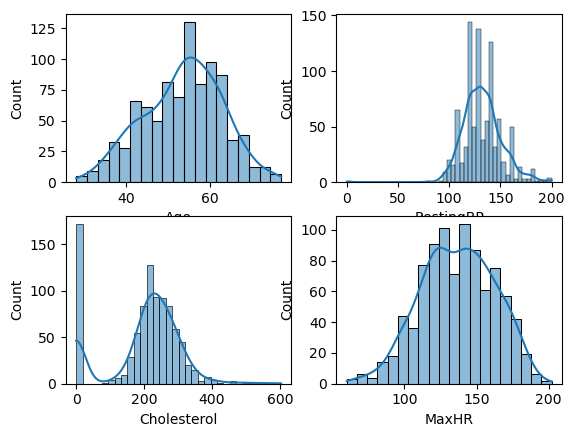

In [9]:
def plot(col,num):
    plt.subplot(2,2,num)
    sns.histplot(df[col],kde=True)
plot("Age",1)
plot("RestingBP",2)
plot("Cholesterol",3)
plot("MaxHR",4)

    

cholestrol mai 0 jyda hai  aur resting bp mai 0 se hai 0 kisi ka bp nhi hota hai  aur 0 cholestrol bhi nhi hota hiai 

In [18]:
df["Cholesterol"].value_counts()

Cholesterol
0      172
254     11
223     10
220     10
230      9
      ... 
392      1
316      1
153      1
466      1
131      1
Name: count, Length: 222, dtype: int64

<!-- mean se fill kr raha hu -->

In [ ]:
# df["Cholesterol"]

In [19]:
ch_mean= df.loc[df["Cholesterol"]!=0,"Cholesterol"].mean()
ch_mean

np.float64(244.6353887399464)

In [20]:
df["Cholesterol"]=df["Cholesterol"].replace(0,ch_mean)
df["Cholesterol"]=df["Cholesterol"].round(2)

<Axes: xlabel='Cholesterol', ylabel='Count'>

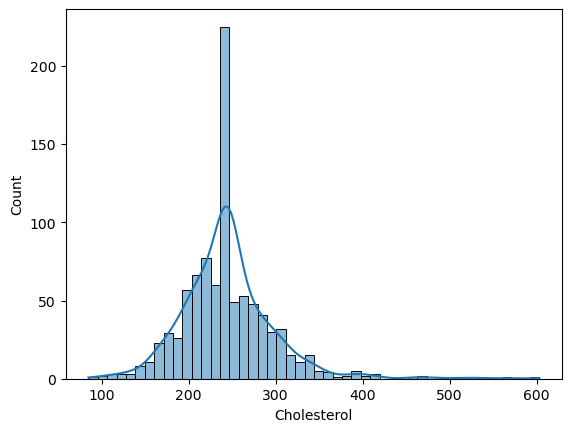

In [23]:
sns.histplot(df["Cholesterol"],kde=True)


resting bp ko 

In [25]:
RestingBp_mean= df.loc[df["Cholesterol"]!=0,"RestingBP"].mean()
df["RestingBP"]=df["RestingBP"].replace(0,RestingBp_mean)
df["RestingBP"]=df["RestingBP"].round(2)

<Axes: xlabel='RestingBP', ylabel='Count'>

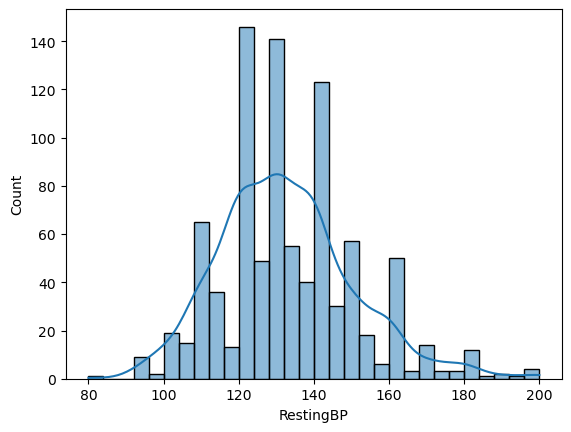

In [26]:
sns.histplot(df["RestingBP"],kde=True)

<Axes: xlabel='Sex', ylabel='count'>

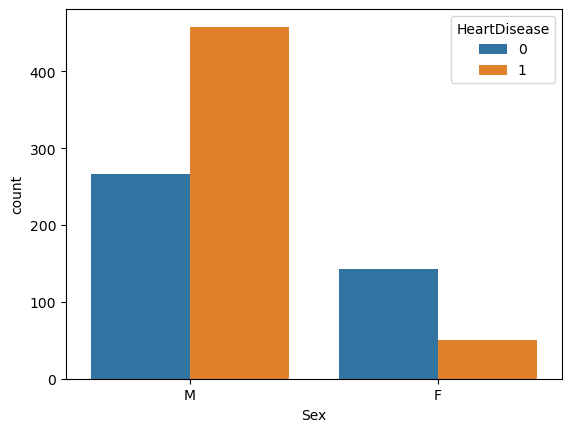

In [28]:
sns.countplot(data= df, x= 'Sex', hue= 'HeartDisease')

In [31]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [33]:
df.dtypes

Age                 int64
Sex                object
ChestPainType      object
RestingBP         float64
Cholesterol       float64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object

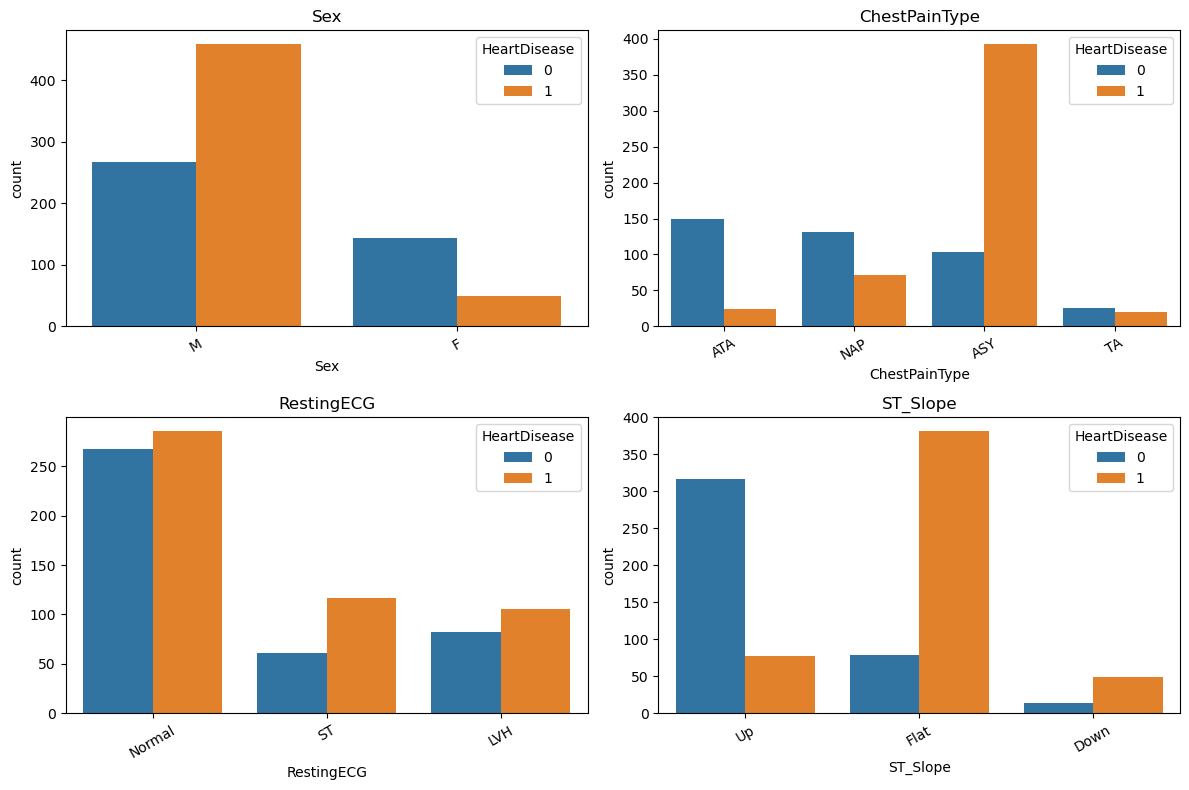

In [36]:
def categorical(col,num):
    plt.subplot(2, 2, num)  
    sns.countplot(data=df, x=col, hue='HeartDisease')
    plt.title(col)
    plt.xticks(rotation=30)  
plt.figure(figsize=(12, 8))
categorical("Sex", 1)
categorical("ChestPainType", 2)
categorical("RestingECG", 3)
categorical("ST_Slope", 4)

plt.tight_layout()
plt.show()
    

In [ ]:
# compare numerical 1 val  aur categorical 1 val ko 

<Axes: xlabel='HeartDisease', ylabel='Cholesterol'>

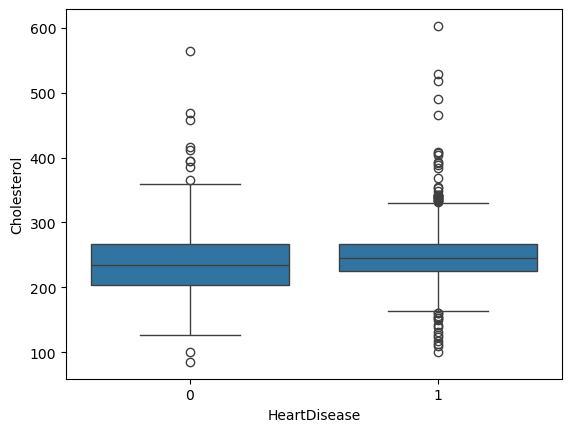

In [42]:
sns.boxplot(x="HeartDisease", y="Cholesterol", data=df)

<Axes: >

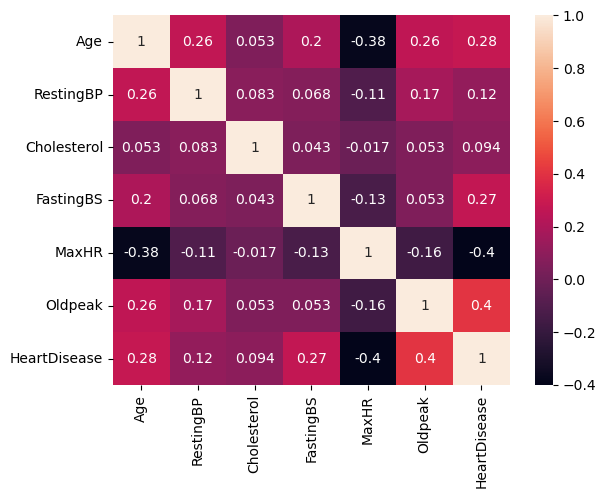

In [43]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

# data preprocessing and cleaning

In [45]:
df_encode=pd.get_dummies(df,drop_first=True)
df_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140.0,289.0,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160.0,180.0,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130.0,283.0,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138.0,214.0,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150.0,195.0,0,122,0.0,0,True,False,True,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110.0,264.0,0,132,1.2,1,True,False,False,True,True,False,False,True,False
914,68,144.0,193.0,1,141,3.4,1,True,False,False,False,True,False,False,True,False
915,57,130.0,131.0,0,115,1.2,1,True,False,False,False,True,False,True,True,False
916,57,130.0,236.0,0,174,0.0,1,False,True,False,False,False,False,False,True,False


In [47]:
df_encode=df_encode.astype(int)

In [48]:
df_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,0,1,1,0,0,1,0,0,0,1
1,49,160,180,0,156,1,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0,0,1,1,0,0,0,1,0,0,1
3,48,138,214,0,108,1,1,0,0,0,0,1,0,1,1,0
4,54,150,195,0,122,0,0,1,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110,264,0,132,1,1,1,0,0,1,1,0,0,1,0
914,68,144,193,1,141,3,1,1,0,0,0,1,0,0,1,0
915,57,130,131,0,115,1,1,1,0,0,0,1,0,1,1,0
916,57,130,236,0,174,0,1,0,1,0,0,0,0,0,1,0


# age, cholestrol resting bp ....etc  numric col h isse scal krenge kyoki iss sab ka val jayda hai 

In [51]:
from sklearn.preprocessing import StandardScaler
numeric_col=['Age', 'RestingBP', 'MaxHR', 'Oldpeak',"Cholesterol"]
scaler=StandardScaler()
df_encode[numeric_col]=scaler.fit_transform(df_encode[numeric_col])


In [53]:
df_encode.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0.414885,0.834754,0,1.382928,-0.727592,0,1,1,0,0,1,0,0,0,1
1,-0.478484,1.527224,-1.210675,0,0.754157,0.282891,1,0,0,1,0,1,0,0,1,0
2,-1.751359,-0.141284,0.722161,0,-1.525138,-0.727592,0,1,1,0,0,0,1,0,0,1
3,-0.584556,0.303651,-0.572651,0,-1.132156,0.282891,1,0,0,0,0,1,0,1,1,0
4,0.051881,0.971054,-0.929194,0,-0.581981,-0.727592,0,1,0,1,0,1,0,0,0,1


In [80]:
# Data split
from sklearn.model_selection import train_test_split

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Metrics
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier


In [81]:
X=df_encode.drop("HeartDisease",axis=1)
y= df_encode["HeartDisease"]

In [82]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [83]:
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(X_train)
x_test_scaled=scaler.fit_transform(X_test)

In [90]:
x_train_scaled

array([[ 0.46471433, -1.85895813, -0.21819285, ..., -0.83034552,
        -1.02524056,  1.15890711],
       [ 0.78176703, -1.29873134, -0.02331276, ...,  1.20431793,
        -1.02524056, -0.86288193],
       [-0.06370685,  1.50240258, -0.02331276, ...,  1.20431793,
         0.97538084, -0.86288193],
       ...,
       [ 0.6760828 , -0.17827778,  0.15207932, ...,  1.20431793,
        -1.02524056,  1.15890711],
       [ 0.6760828 ,  1.05422115, -0.02331276, ...,  1.20431793,
        -1.02524056,  1.15890711],
       [-1.43760192,  0.94217579,  2.86091257, ..., -0.83034552,
         0.97538084, -0.86288193]], shape=(642, 15))

In [84]:
models = {
    "Logistic_Regression": LogisticRegression(),
    "Naive Bayes": GaussianNB(),
    "SVC": SVC(),
    "Decision tree": DecisionTreeClassifier(),
    "KNN": KNeighborsClassifier()
}

In [85]:
result=[]

In [86]:
for name, model in models.items():
    model.fit(x_train_scaled, y_train)
    y_pred = model.predict(X_test)

    # Metrics
    Accuracy = accuracy_score(y_test, y_pred)
    F1_Score = f1_score(y_test, y_pred, average='binary')  # change to 'macro' if multi-class

    # Append results
    result.append({
        "Model": name,
        "Accuracy": round(Accuracy, 4),
        "F1": round(F1_Score, 4)
    })

In [87]:
result

[{'Model': 'Logistic_Regression', 'Accuracy': 0.8696, 'F1': 0.8947},
 {'Model': 'Naive Bayes', 'Accuracy': 0.8514, 'F1': 0.8761},
 {'Model': 'SVC', 'Accuracy': 0.8442, 'F1': 0.8775},
 {'Model': 'Decision tree', 'Accuracy': 0.7971, 'F1': 0.8272},
 {'Model': 'KNN', 'Accuracy': 0.8442, 'F1': 0.8716}]

In [88]:
import pickle
import joblib

In [89]:
joblib.dump(models["Logistic_Regression"], "logistic_model.pkl")

# Save scaler
joblib.dump(scaler, "scaler.pkl")

# Save column names list
joblib.dump(X.columns.tolist(), "columns.pkl")

['columns.pkl']